# 💥Grover Search Lab💥
**Question:** Does adding more Grover iterations always increase the probability of finding a target?

Build a three-qubit phase oracle, apply diffusion, and compare exact theory with simulation and sampled outcomes. Default target: `101`; search space: eight basis states.

رح نلاحظ كيف ترتفع احتمالية الحالة المطلوبة، وبعدها تنخفض إذا تجاوزنا عدد التكرارات المناسب للقمة الأولى



In [1]:
# Run once if Qiskit is not installed (e.g. in Google Colab):
# %pip install qiskit==2.2.3 numpy==2.3.5 matplotlib==3.10.8 ipywidgets
import sys
import qiskit
print("Python:", sys.version.split()[0], "| Qiskit:", qiskit.__version__)


Python: 3.12.14 | Qiskit: 2.2.3


## 1. What the experiment models
Prepare the uniform state $|s\rangle$ with one Hadamard per qubit. The oracle flips only the target amplitude's sign. Diffusion applies $D=2|s\rangle\langle s|-I$. Each Grover iteration is oracle followed by diffusion.

For one marked state among $N=2^n$ possibilities:
$$\theta=\arcsin(1/\sqrt{N}),\qquad P_k=\sin^2((2k+1)\theta).$$

The first continuous maximum occurs at $k=\pi/(4\theta)-1/2$. Compare its neighboring integers. For $N=8$, the first-peak choice is $k=2$.

The target is built into the teaching oracle. This is not a search of a real external database. Simulation time is not evidence of quantum speedup.

## 2. Reusable implementation
Bitstrings use `|q₂ q₁ q₀〉`: the rightmost bit belongs to qubit 0. Try `001` to make ordering visible.

In [2]:
"""Study Grover amplitude amplification on a small, ideal simulated search space."""
from pathlib import Path
import csv
import json
import platform

import matplotlib.pyplot as plt
import numpy as np
import qiskit
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


def validate_target(target):
    if not isinstance(target, str) or not 2 <= len(target) <= 8 or set(target) - {"0", "1"}:
        raise ValueError("target must be a 2–8 character bitstring, e.g. '101'")


def phase_oracle(target):
    """Flip the sign of |target>. Strings use Qiskit's |q_(n-1)...q_0> order."""
    validate_target(target)
    n = len(target)
    circuit = QuantumCircuit(n, name="Oracle")
    zero_qubits = [i for i, bit in enumerate(reversed(target)) if bit == "0"]
    for qubit in zero_qubits:
        circuit.x(qubit)
    circuit.h(n - 1)
    circuit.mcx(list(range(n - 1)), n - 1)
    circuit.h(n - 1)
    for qubit in zero_qubits:
        circuit.x(qubit)
    return circuit


def diffuser(n):
    """Implement D = 2|s><s| - I, including its conventional global phase."""
    if not isinstance(n, int) or not 2 <= n <= 8:
        raise ValueError("n must be an integer from 2 to 8")
    circuit = QuantumCircuit(n, name="Diffuser")
    circuit.h(range(n))
    circuit.x(range(n))
    circuit.h(n - 1)
    circuit.mcx(list(range(n - 1)), n - 1)
    circuit.h(n - 1)
    circuit.x(range(n))
    circuit.h(range(n))
    # The gates above produce -D. This global phase makes the matrix exactly D.
    circuit.global_phase += np.pi
    return circuit


def grover_circuit(target="101", iterations=2):
    validate_target(target)
    if not isinstance(iterations, (int, np.integer)) or iterations < 0:
        raise ValueError("iterations must be a nonnegative integer")
    n = len(target)
    circuit = QuantumCircuit(n)
    circuit.h(range(n))
    for _ in range(iterations):
        circuit.compose(phase_oracle(target), inplace=True)
        circuit.compose(diffuser(n), inplace=True)
    return circuit


def theoretical_success(n, iterations):
    """Single marked state, uniform initial state, ideal oracle and diffusion."""
    theta = np.arcsin(1 / np.sqrt(2**n))
    return np.sin((2 * np.asarray(iterations) + 1) * theta)**2


def first_peak_iterations(n):
    """Choose the better integer adjacent to the first continuous maximum."""
    theta = np.arcsin(1 / np.sqrt(2**n))
    peak = np.pi / (4 * theta) - .5
    candidates = [max(0, int(np.floor(peak))), max(0, int(np.ceil(peak)))]
    return max(candidates, key=lambda k: float(theoretical_success(n, k)))


def run_experiment(output_dir="results/grover", target="101", max_iterations=8,
                   shots=4096, seed=123):
    validate_target(target)
    if not isinstance(max_iterations, int) or max_iterations < 1:
        raise ValueError("max_iterations must be a positive integer")
    if not isinstance(shots, int) or shots <= 0:
        raise ValueError("shots must be a positive integer")
    output = Path(output_dir)
    output.mkdir(parents=True, exist_ok=True)
    n = len(target)
    labels = [format(i, f"0{n}b") for i in range(2**n)]
    target_index = int(target, 2)
    rng = np.random.default_rng(seed)
    records, detailed, distributions = [], [], {}
    for k in range(max_iterations + 1):
        p = Statevector.from_instruction(grover_circuit(target, k)).probabilities()
        p = np.clip(p, 0, 1)
        counts = rng.multinomial(shots, p / p.sum())
        distributions[k] = (p, counts)
        records.append({"iterations": k, "oracle_calls": k, "target": target,
                        "exact_success": float(p[target_index]),
                        "theory_success": float(theoretical_success(n, k)),
                        "sampled_success": float(counts[target_index]/shots),
                        "target_counts": int(counts[target_index]), "shots": shots})
        for label, probability, count in zip(labels, p, counts):
            detailed.append({"iterations": k, "bitstring": label,
                             "exact_probability": float(probability),
                             "counts": int(count), "shots": shots})
    for name, rows in [("iteration_sweep.csv", records), ("all_outcomes.csv", detailed)]:
        with (output / name).open("w", newline="", encoding="utf-8") as f:
            writer = csv.DictWriter(f, fieldnames=list(rows[0]))
            writer.writeheader()
            writer.writerows(rows)

    plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                         "axes.spines.right": False, "figure.facecolor": "white"})
    fig, ax = plt.subplots(figsize=(9, 4.8), constrained_layout=True)
    ks = np.arange(max_iterations + 1)
    ax.plot(ks, [r["theory_success"] for r in records], color="#176B58",
            linewidth=2, label="Theory at integer iterations")
    ax.scatter(ks, [r["exact_success"] for r in records], facecolors="none",
               edgecolors="black", s=80, label="Exact statevector")
    ax.scatter(ks, [r["sampled_success"] for r in records], color="#7465A8",
               s=23, label=f"Sampled: {shots:,} shots / circuit")
    first = first_peak_iterations(n)
    if first <= max_iterations:
        ax.axvline(first, color="#A6B8AC", linestyle=":", label=f"First-peak choice: k={first}")
    ax.axhline(1/2**n, color="#999999", linestyle="--", label="Uniform baseline")
    ax.set(xticks=ks, ylim=(-.04, 1.05), xlabel="Grover iterations (oracle calls)",
           ylabel=f"Probability of finding {target}",
           title="Grover success oscillates: more iterations are not always better")
    ax.legend(fontsize=9, loc="upper center", bbox_to_anchor=(.5, -.18), ncol=2)
    fig.savefig(output / "success_vs_iterations.png", dpi=170)
    plt.close(fig)

    chosen = sorted(set([0, min(first, max_iterations), min(first+1, max_iterations)]))
    fig, axes = plt.subplots(1, len(chosen), figsize=(12, 4), constrained_layout=True, squeeze=False)
    x = np.arange(2**n)
    for ax, k in zip(axes[0], chosen):
        p, counts = distributions[k]
        ax.bar(x-.18, p, width=.36, color="#176B58", label="Exact")
        ax.bar(x+.18, counts/shots, width=.36, color="#B5A7D0", label="Sampled")
        ax.set(xticks=x, xticklabels=labels, ylim=(0, 1.05),
               xlabel=r"Outcome $|q_{n-1}\ldots q_0\rangle$", title=f"k = {k} | target {target}")
        ax.tick_params(axis="x", rotation=60, labelsize=8)
        ax.set_ylabel("Probability")
        ax.legend(fontsize=9)
    fig.savefig(output / "outcome_distributions.png", dpi=170)
    plt.close(fig)

    metadata = {"experiment": "Grover Search Lab", "target": target, "qubits": n,
                "shots_per_circuit": shots, "seed": seed,
                "max_iterations": max_iterations, "first_peak_choice": first,
                "python": platform.python_version(), "qiskit": qiskit.__version__,
                "numpy": np.__version__,
                "max_absolute_theory_error": max(abs(r["exact_success"]-r["theory_success"]) for r in records),
                "backend": "Ideal Qiskit Statevector; NumPy multinomial sampling",
                "hardware_run": False,
                "note": "First-peak choice is not a global maximum across arbitrarily many iterations."}
    (output / "metadata.json").write_text(json.dumps(metadata, indent=2)+"\n", encoding="utf-8")
    return records




In [3]:
TARGET = "101"
ITERATIONS = 2
print(grover_circuit(TARGET, ITERATIONS).draw(output="text", fold=95))
print("First-peak choice:", first_peak_iterations(len(TARGET)))

     ┌───┐          ┌───┐┌───┐               ┌───┐┌───┐               ┌───┐┌───┐          »
q_0: ┤ H ├───────■──┤ H ├┤ X ├────────────■──┤ X ├┤ H ├────────────■──┤ H ├┤ X ├──────────»
     ├───┤┌───┐  │  ├───┤├───┤┌───┐       │  ├───┤├───┤┌───┐       │  ├───┤├───┤┌───┐     »
q_1: ┤ H ├┤ X ├──■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├───────■──┤ X ├┤ H ├┤ X ├─────»
     ├───┤├───┤┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤├───┤├───┤┌───┐┌─┴─┐├───┤├───┤├───┤┌───┐»
q_2: ┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├┤ H ├┤ X ├┤ H ├»
     └───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘└───┘»
«          ┌───┐┌───┐     
«q_0: ──■──┤ X ├┤ H ├─────
«       │  ├───┤├───┤     
«q_1: ──■──┤ X ├┤ H ├─────
«     ┌─┴─┐├───┤├───┤┌───┐
«q_2: ┤ X ├┤ H ├┤ X ├┤ H ├
«     └───┘└───┘└───┘└───┘
First-peak choice: 2


## 3. Measure the iteration sweep
Each circuit uses an exact statevector and 4,096 classical draws from its ideal distribution. No hardware noise or decoherence is included.

 k | theory   | exact    | sampled
 0 | 0.125000 | 0.125000 | 0.121338
 1 | 0.781250 | 0.781250 | 0.769287
 2 | 0.945313 | 0.945312 | 0.947510
 3 | 0.330078 | 0.330078 | 0.333984
 4 | 0.012207 | 0.012207 | 0.013184
 5 | 0.547974 | 0.547974 | 0.566895
 6 | 0.999786 | 0.999786 | 1.000000
 7 | 0.576973 | 0.576973 | 0.565186
 8 | 0.019457 | 0.019457 | 0.024170


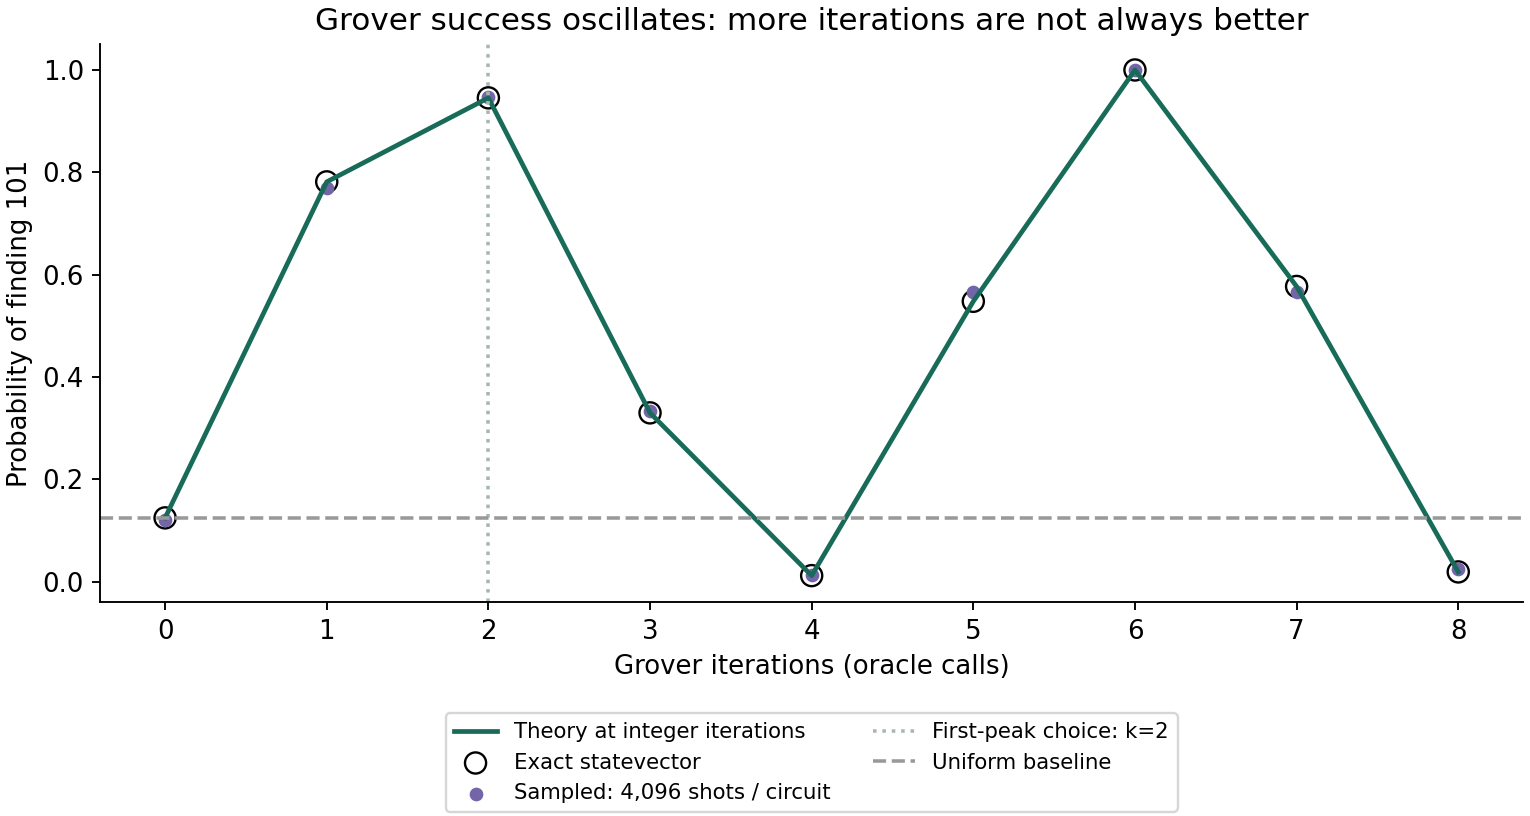

In [4]:
records = run_experiment(target=TARGET, max_iterations=8, shots=4096, seed=123)
print(" k | theory   | exact    | sampled")
for row in records:
    print(f"{row['iterations']:2d} | {row['theory_success']:.6f} | {row['exact_success']:.6f} | {row['sampled_success']:.6f}")
from IPython.display import Image, display
display(Image(filename="results/grover/success_vs_iterations.png"))

## 4. Read the result carefully
The exact success probabilities for $k=0,1,2,3$ are **12.5%, 78.125%, 94.53125%, 33.0078125%**.
The third iteration overshoots the first peak. Later peaks can be higher; for example, $k=6$ is higher than $k=2$, but costs more oracle calls. Therefore, two iterations is a first-peak stopping choice, not a global maximum over every possible iteration count.

  الهدف مو انو ا نكرر الخطوات قد ما نقدر ،، نختار عدا مناسب للتكرارات ونوازن احتمالية النجاح مع عدد استدعاءات الoracle

Maximum exact–theory difference: 1.15e-14


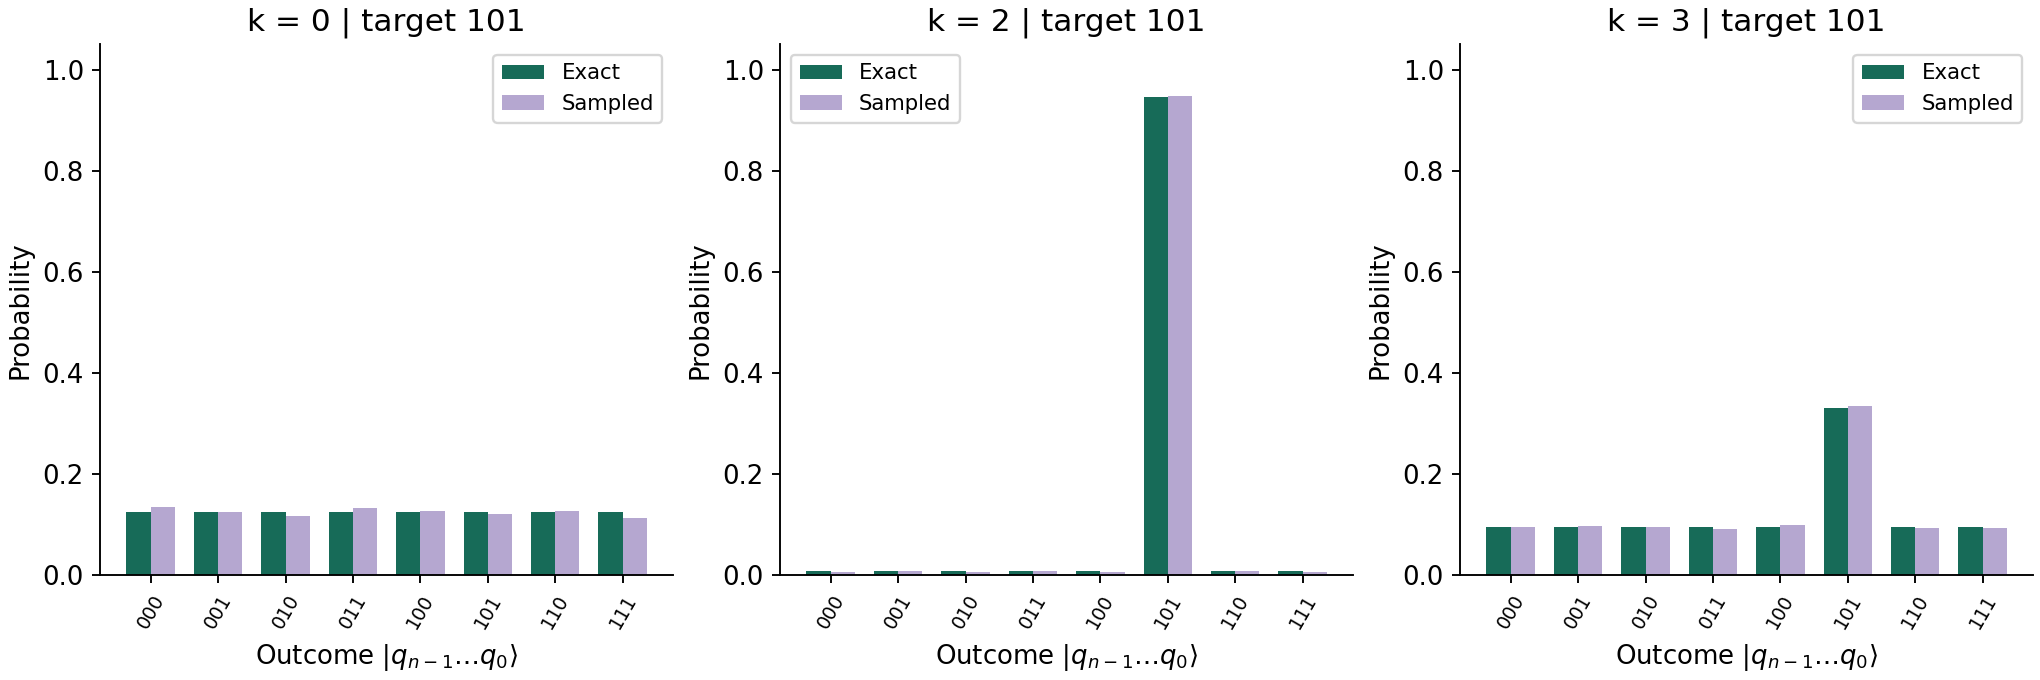

In [5]:
display(Image(filename="results/grover/outcome_distributions.png"))
error = max(abs(r["exact_success"] - r["theory_success"]) for r in records)
print(f"Maximum exact–theory difference: {error:.2e}")
assert error < 1e-10

## 5. Inspect amplitudes before and after one iteration
The oracle changes signs, not measurement probabilities. The following diffusion converts that sign pattern into amplitude amplification.

In [6]:
n = len(TARGET)
prepare = QuantumCircuit(n)
prepare.h(range(n))
uniform = Statevector.from_instruction(prepare)
after_oracle = uniform.evolve(phase_oracle(TARGET))
after_diffusion = after_oracle.evolve(diffuser(n))
for label, state in [("Uniform", uniform), ("After oracle", after_oracle),
                     ("After diffusion", after_diffusion)]:
    print(label, "amplitudes:", np.round(state.data.real, 4))
    print("Target probability:", round(float(state.probabilities()[int(TARGET, 2)]), 6))

Uniform amplitudes: [0.3536 0.3536 0.3536 0.3536 0.3536 0.3536 0.3536 0.3536]
Target probability: 0.125
After oracle amplitudes: [-0.3536 -0.3536 -0.3536 -0.3536 -0.3536  0.3536 -0.3536 -0.3536]
Target probability: 0.125
After diffusion amplitudes: [0.1768 0.1768 0.1768 0.1768 0.1768 0.8839 0.1768 0.1768]
Target probability: 0.78125


## 6. Explore target and iteration count


In [7]:
CUSTOM_TARGET = "001"
CUSTOM_ITERATIONS = 3
p = Statevector.from_instruction(grover_circuit(CUSTOM_TARGET, CUSTOM_ITERATIONS)).probabilities()
print(f"P({CUSTOM_TARGET}) = {p[int(CUSTOM_TARGET, 2)]:.6f}")

P(001) = 0.330078


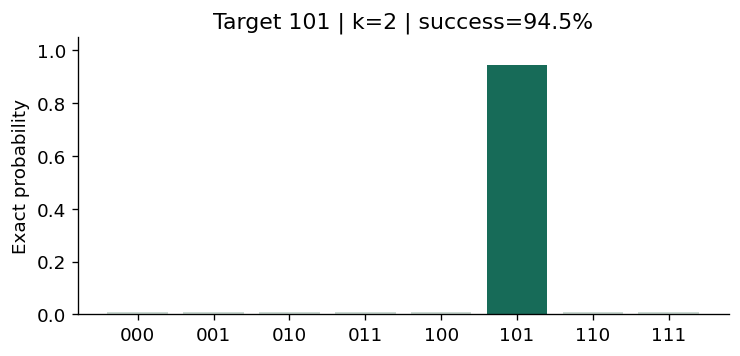

In [8]:
def explore_grover(target, iterations):
    p = Statevector.from_instruction(grover_circuit(target, iterations)).probabilities()
    labels = [format(i, "03b") for i in range(8)]
    colors = ["#176B58" if x == target else "#CBD9D2" for x in labels]
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.bar(labels, p, color=colors)
    ax.set(ylim=(0, 1.05), ylabel="Exact probability",
           title=f"Target {target} | k={iterations} | success={p[int(target, 2)]:.1%}")
    from io import BytesIO
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

try:
    import os
    if os.environ.get("QUANTUM_LABS_STATIC_RUN") == "1":
        raise ImportError("Static execution: show the default experiment")
    from ipywidgets import interact, Dropdown, IntSlider
    interact(explore_grover,
             target=Dropdown(options=[format(i, "03b") for i in range(8)], value="101"),
             iterations=IntSlider(value=2, min=0, max=8, continuous_update=False))
except ImportError:
    explore_grover("101", 2)




**Sources:** [IBM: Grover iteration count](https://quantum.cloud.ibm.com/learning/en/courses/fundamentals-of-quantum-algorithms/grover-algorithm/number-of-iterations), [IBM: Grover overview](https://quantum.cloud.ibm.com/learning/en/modules/computer-science/grovers), [Qiskit QuantumCircuit](https://quantum.cloud.ibm.com/docs/en/api/qiskit/2.2/qiskit.circuit.QuantumCircuit).
